# Titanic Survival Prediction using Machine Learning

This project predicts whether a passenger survived the Titanic disaster using machine learning. The workflow includes data cleaning, exploratory data analysis (EDA), feature engineering, preprocessing, model comparison, hyperparameter tuning using GridSearchCV, and Kaggle submission.

# Dataset

Dataset Source:

https://www.kaggle.com/competitions/titanic

The dataset contains passenger information such as:

Passenger Class
Name
Sex
Age
Fare
Cabin
Embarked
Number of Siblings/Spouses
Number of Parents/Children

Target Variable:

Survived
0 = Did Not Survive
1 = Survived

# Import Libraries

Import all the necessary Python libraries required for data manipulation, visualization, preprocessing, model training, evaluation, and hyperparameter tuning.

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
train=pd.read_csv("train.csv")

In [6]:
test=pd.read_csv("test.csv")

# Initial Data Exploration

Explore the dataset using functions such as `head()`, `shape`, `info()`, and `describe()` to understand the overall structure, feature types, and missing values.

In [7]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [13]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [15]:
train.duplicated().sum()

np.int64(0)

In [16]:
test.duplicated().sum()

np.int64(0)

# Distribution Analysis

Analyze the distribution of numerical features and measure skewness to identify potential transformations before model training.

In [17]:
def item(df):
    for col in df.columns:
        print(f"Column:{col}\n")
        print(df[col].value_counts())
        print("-----"*50)

In [18]:
def check_skew(df):
    return df.skew(numeric_only=True)

In [19]:
check_skew(train)

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64

In [20]:
item(train)

Column:PassengerId

PassengerId
1      1
599    1
588    1
589    1
590    1
      ..
301    1
302    1
303    1
304    1
891    1
Name: count, Length: 891, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column:Survived

Survived
0    549
1    342
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column:Pclass

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [21]:
check_skew(test)

PassengerId    0.000000
Pclass        -0.534170
Age            0.457361
SibSp          4.168337
Parch          4.654462
Fare           3.687213
dtype: float64

In [22]:
item(test)

Column:PassengerId

PassengerId
892     1
1205    1
1177    1
1176    1
1175    1
       ..
1028    1
1027    1
1026    1
1025    1
1309    1
Name: count, Length: 418, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column:Pclass

Pclass
3    218
1    107
2     93
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column:Name

Name
Kelly, Mr. James               1
Carr, Miss. Jeannie            1
Dennis, Mr. William            1
Rosblom, Miss. Salli Helena    1
Touma, Miss. Maria Youssef     1
                              ..
Zakarian, Mr. Mapriededer 

# Data Cleaning

Handle missing values, remove inconsistencies, and create additional features from the existing dataset to improve predictive performance

In [23]:
train["Age"]=train["Age"].fillna(train["Age"].median())

In [24]:
test["Age"]=test["Age"].fillna(test["Age"].median())

In [25]:
train["Family Size"]=train["SibSp"]+train["Parch"]+1

In [26]:
test["Family Size"]=test["SibSp"]+test["Parch"]+1

In [27]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [28]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3


In [29]:
train["IsAlone"]=(train["Family Size"]==1).astype(int)

In [30]:
test["IsAlone"]=(test["Family Size"]==1).astype(int)

In [31]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


In [32]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,1,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,2,0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,1,1
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,1,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,3,0


In [33]:
train['Title'] = train['Name'].str.extract(r",\s*([^.]+)")

In [34]:
train["Title"].loc[759]

'the Countess'

In [35]:
test['Title'] = test['Name'].str.extract(r",\s*([^.]+)")

In [36]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr


In [37]:
train["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [38]:
test["Title"].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [39]:
rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don",
    "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona","the Countess"
]

In [40]:
train["Title"]=train["Title"].replace({"Mlle":"Miss",
                                      "Mme":"Mrs",
                                      "Ms":"Miss"})

In [41]:
test["Title"]=test["Title"].replace({"Mlle":"Miss",
                                      "Mme":"Mrs",
                                      "Ms":"Miss"})

In [42]:
train["Title"]=train["Title"].replace(rare_titles,"rare")

In [43]:
test["Title"]=test["Title"].replace(rare_titles,"rare")

In [44]:
train["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
rare       23
Name: count, dtype: int64

In [45]:
test["Title"].value_counts()

Title
Mr        240
Miss       79
Mrs        72
Master     21
rare        6
Name: count, dtype: int64

In [46]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr


## Fare Transformation

Visualize the Fare distribution and apply logarithmic transformation (`log1p`) to reduce skewness.

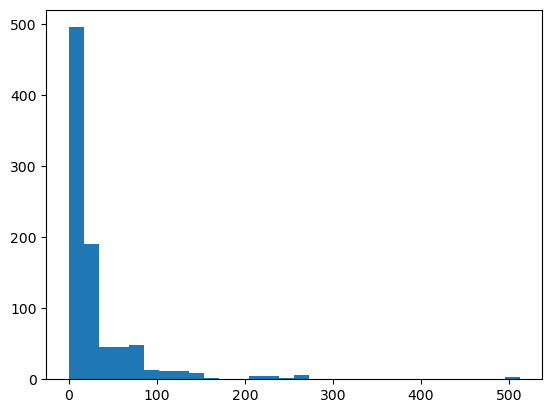

In [47]:
plt.hist(train["Fare"],bins=30)
plt.show()

In [48]:
test["Fare"]=test["Fare"].fillna(test["Fare"].median())

In [49]:
fare_skew_check=np.log1p(train["Fare"])

In [50]:
fare_skewcheck_test=np.log1p(test["Fare"])

In [51]:
fare_skew_check.skew()

np.float64(0.3949280095189306)

In [52]:
fare_skewcheck_test.skew()

np.float64(0.86495458308337)

In [53]:
test["Fare"].skew()

np.float64(3.6922987243405156)

In [54]:
train["Fare"]=np.log1p(train["Fare"])

In [55]:
test["Fare"]=np.log1p(test["Fare"])

In [56]:
train["Age"].skew()

np.float64(0.5102446555756495)

## Deck Extraction

Extract deck information from the Cabin feature after replacing missing values with **No Info**.

In [57]:
train["Deck"]=train["Cabin"].fillna("No Info")

In [58]:
test["Deck"]=test["Cabin"].fillna("No Info")

In [59]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone,Title,Deck
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,2.110213,NaN,S,2,0,Mr,No Info
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,4.280593,C85,C,2,0,Mrs,C85
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,2.188856,NaN,S,1,1,Miss,No Info
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,3.990834,C123,S,2,0,Mrs,C123
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,2.202765,NaN,S,1,1,Mr,No Info


In [60]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone,Title,Deck
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,2.178064,NaN,Q,1,1,Mr,No Info
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,2.079442,NaN,S,2,0,Mrs,No Info
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,2.369075,NaN,Q,1,1,Mr,No Info
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,2.268252,NaN,S,1,1,Mr,No Info
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,2.586824,NaN,S,3,0,Mrs,No Info


In [61]:
def mod_cabin(df):
    df["Deck"]=df["Deck"].apply(lambda x: x[0] if x != "No Info" else "No Info")

In [62]:
mod_cabin(train)

In [63]:
mod_cabin(test)

In [64]:
train["Deck"].value_counts()

Deck
No Info    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [65]:
test["Deck"].value_counts()

Deck
No Info    327
C           35
B           18
D           13
E            9
F            8
A            7
G            1
Name: count, dtype: int64

## Final Data Cleaning

Complete the remaining preprocessing steps by handling missing categorical values and removing unnecessary columns.

In [66]:
train["Embarked"]=train["Embarked"].fillna(train["Embarked"].mode()[0])

In [67]:
test["Embarked"]=test["Embarked"].fillna(test["Embarked"].mode()[0])

In [68]:
train.drop(columns=["Name",
                   "SibSp",
                   "Parch",
                   "Ticket",
                   "Cabin"],inplace=True)

In [69]:
test.drop(columns=["Name",
                   "SibSp",
                   "Parch",
                   "Ticket",
                   "Cabin"],inplace=True)

# Exploratory Data Analysis (EDA)

Visualize the relationship between important features and passenger survival to identify meaningful patterns before model training.

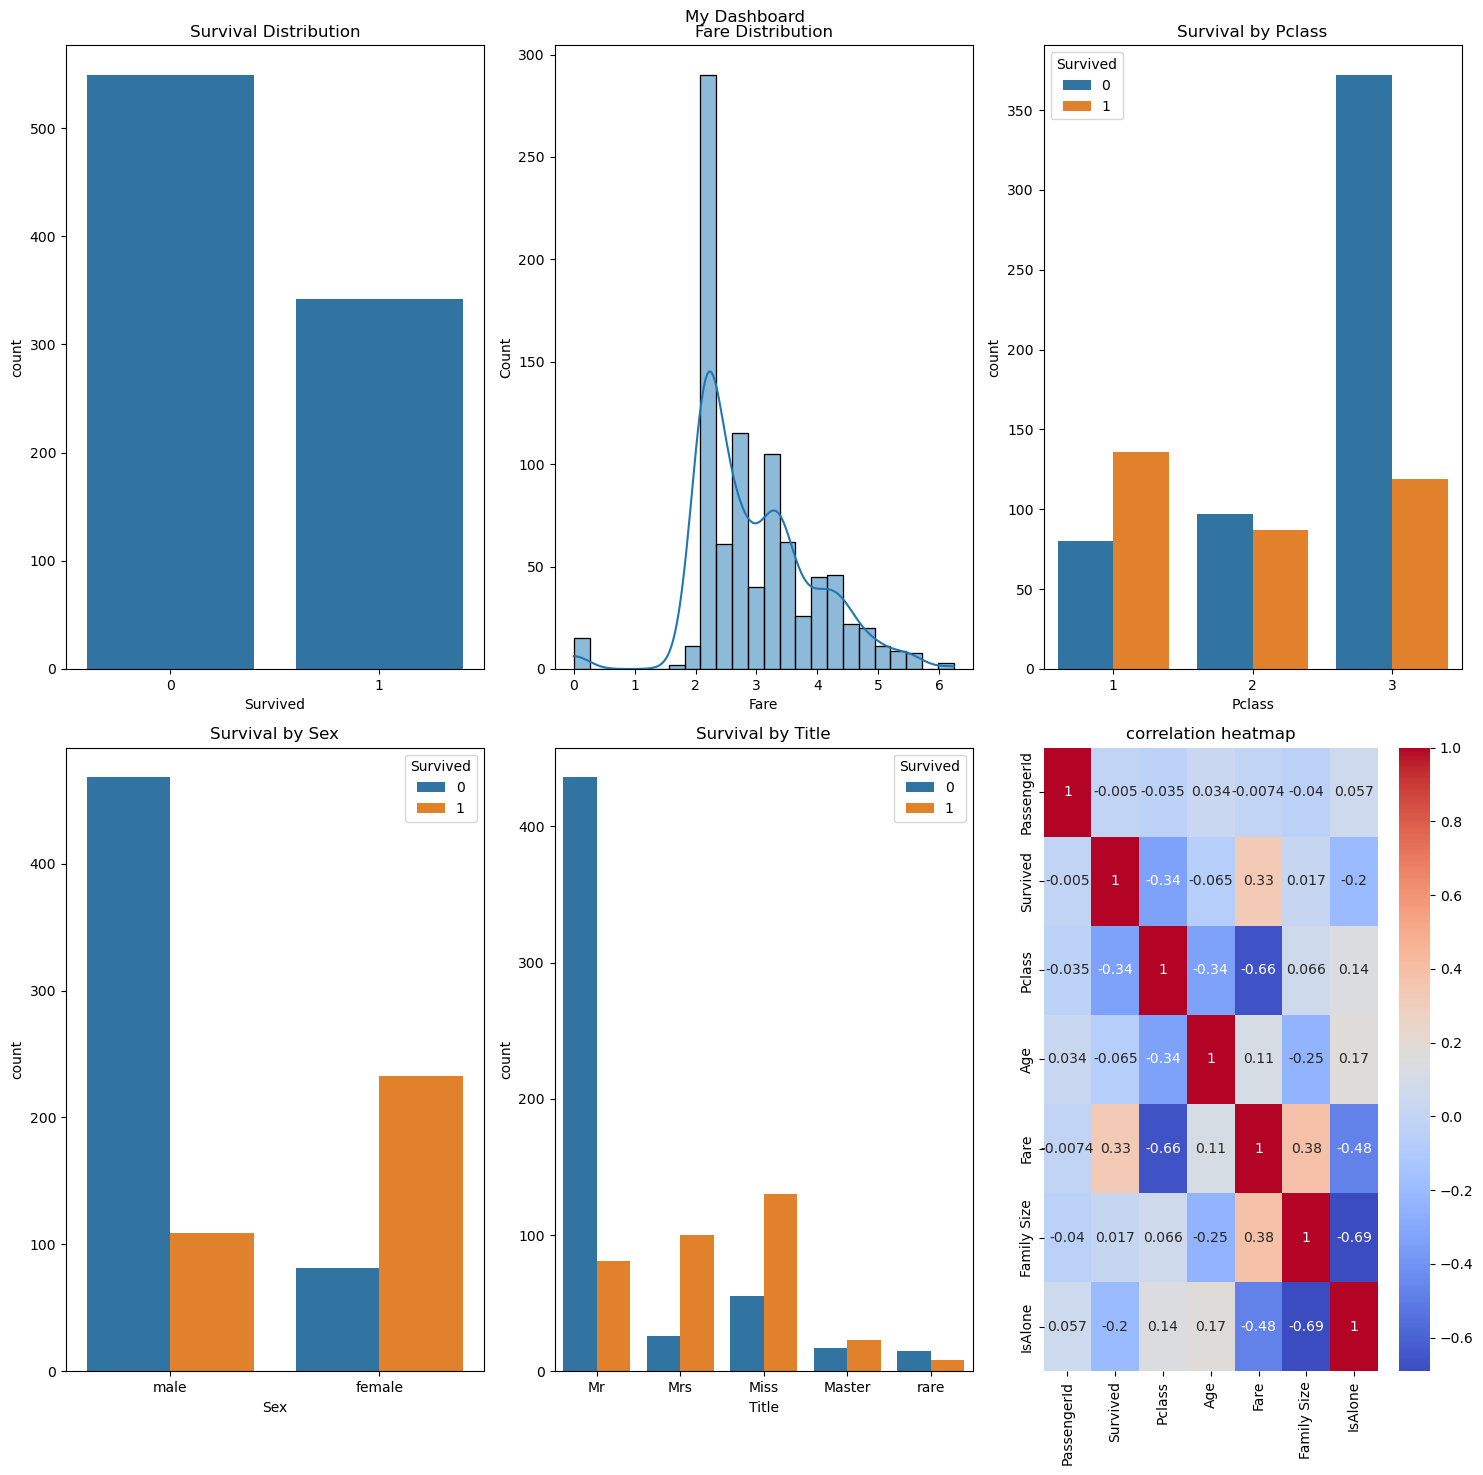

In [71]:
fig,ax=plt.subplots(2,3,figsize=(15,15))
fig.suptitle("My Dashboard")

sns.countplot(x="Survived",data=train,ax=ax[0,0])
ax[0,0].set_title("Survival Distribution")

sns.histplot(train["Fare"],kde=True,ax=ax[0,1])
ax[0,1].set_title("Fare Distribution")

sns.countplot(x="Pclass",hue="Survived",data=train,ax=ax[0,2])
ax[0,2].set_title("Survival by Pclass")

sns.countplot(x="Sex",hue="Survived",data=train,ax=ax[1,0])
ax[1,0].set_title("Survival by Sex")

sns.countplot(x="Title",hue="Survived",data=train,ax=ax[1,1])
ax[1,1].set_title("Survival by Title")

sns.heatmap(train.corr(numeric_only=True),annot=True,cmap="coolwarm",ax=ax[1,2])
ax[1,2].set_title("correlation heatmap")

fig.tight_layout()
plt.show()

# Import Machine Learning Libraries

Import the required libraries for preprocessing, model training, evaluation, pipelines, and hyperparameter tuning.

In [72]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV

In [73]:
from sklearn.compose import ColumnTransformer

In [74]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [75]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [76]:
from sklearn.pipeline import Pipeline

# Train-Test Split

Separate the features and target variable, then split the training data into training and validation sets.

In [78]:
x=train.drop(columns=["Survived","PassengerId"],axis=1)
y=train["Survived"]

In [79]:
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)

# Data Preprocessing

Use a ColumnTransformer to apply One-Hot Encoding to categorical features and Standard Scaling to numerical features.

In [80]:
preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False),["Sex",
                                                                                                                "Embarked",
                                                                                                                "Title",
                                                                                                               "Deck"]),
                                             ("num",StandardScaler(),["Pclass","Fare","Age","Family Size"])
                                            ],remainder='passthrough')

In [81]:
Model=None
Cross_val_score=0
Accuracy_score=0
results=[]

In [82]:
from sklearn.neighbors import KNeighborsClassifier

In [83]:
from sklearn.svm import SVC

In [84]:
from sklearn.linear_model import LogisticRegression

# Model Training

Train and compare multiple machine learning classification models using the same preprocessing pipeline.

In [85]:
models={"KNN":KNeighborsClassifier(),
       "SVM":SVC(),
       "Logistic Regression":LogisticRegression()}

In [86]:
for name , model in models.items():
    clf=Pipeline(steps=[("preprocessor",preprocessor),
                       ("model",model)])
    clf.fit(x_train,y_train)

    cross_score=cross_val_score(clf,
                                x_train,
                                y_train,
                                cv=5,
                                scoring="accuracy").mean()*100

    pred=clf.predict(x_val)
    score=accuracy_score(y_val,pred)*100
    cm=confusion_matrix(y_val,pred)
    cr=classification_report(y_val,pred)

    print("---"*50)
    print(f"model name:{name}")
    print(f"cross_val_score:{cross_score:.2f}")
    print(f"accuracy_score:{score:.2f}")
    print(f"confusion_matrix:\n{cm}")
    print(f"classificatoin_report:\n{cr}")

    results.append({"Model":name,
                    "Cross_val_score":round(cross_score,2),
                    "Accuracy_score":round(score,2)})

------------------------------------------------------------------------------------------------------------------------------------------------------
model name:KNN
cross_val_score:81.18
accuracy_score:83.80
confusion_matrix:
[[93 12]
 [17 57]]
classificatoin_report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.77      0.80        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

------------------------------------------------------------------------------------------------------------------------------------------------------
model name:SVM
cross_val_score:83.56
accuracy_score:82.12
confusion_matrix:
[[92 13]
 [19 55]]
classificatoin_report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81   

In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
from sklearn.ensemble import RandomForestClassifier

# Tree-Based Models

Prepare a separate preprocessing pipeline for Decision Tree and Random Forest models without feature scaling.

In [89]:
tree_preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False),["Sex",
                                                                                                                "Embarked",
                                                                                                                "Title",
                                                                                                               "Deck"])],remainder='passthrough')

In [90]:
models={"Decision Tree":DecisionTreeClassifier(random_state=42),
       "Random Forest":RandomForestClassifier(random_state=42)}

In [91]:
for name, model in models.items():
    tree_clf=Pipeline(steps=[("preprocessor",tree_preprocessor),
                            ("model",model)])
    tree_clf.fit(x_train,y_train)

    cross_score=cross_val_score(tree_clf,
                                x_train,
                                y_train,
                                cv=5,
                                scoring="accuracy").mean()*100

    pred=tree_clf.predict(x_val)
    score=accuracy_score(y_val,pred)*100
    cm=confusion_matrix(y_val,pred)
    cr=classification_report(y_val,pred)

    print("---"*50)
    print(f"model name:{name}")
    print(f"cross_val_score:{cross_score:.2f}")
    print(f"accuracy_score:{score:.2f}")
    print(f"confusion_matrix:\n{cm}")
    print(f"classificatoin_report:\n{cr}")

    results.append({"Model":name,
                    "Cross_val_score":round(cross_score,2),
                    "Accuracy_score":round(score,2)})

------------------------------------------------------------------------------------------------------------------------------------------------------
model name:Decision Tree
cross_val_score:78.24
accuracy_score:78.21
confusion_matrix:
[[87 18]
 [21 53]]
classificatoin_report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       105
           1       0.75      0.72      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

------------------------------------------------------------------------------------------------------------------------------------------------------
model name:Random Forest
cross_val_score:80.20
accuracy_score:81.56
confusion_matrix:
[[88 17]
 [16 58]]
classificatoin_report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
      

# Hyperparameter Tuning

Three models were selected for hyperparameter tuning using **GridSearchCV** based on their initial evaluation results.

The baseline performance of all classification models was compared using **Cross Validation Score**, **Validation Accuracy**, **Confusion Matrix**, and **Classification Report**.

Among all the models, **Support Vector Machine (SVM)**, **Logistic Regression**, and **K-Nearest Neighbors (KNN)** demonstrated the strongest overall performance, achieving similar cross-validation and validation accuracy scores.

Since these models consistently outperformed the Decision Tree and Random Forest classifiers, they were selected as the candidate models for hyperparameter optimization using **GridSearchCV**.

The objective of hyperparameter tuning is to identify the optimal combination of parameters that maximizes the model's generalization performance.

In [92]:
compare=pd.DataFrame(results)

In [93]:
compare

,Model,Cross_val_score,Accuracy_score
0,KNN,81.18,83.80
1,SVM,83.56,82.12
2,Logistic Regression,83.14,82.68
3,Decision Tree,78.24,78.21
4,Random Forest,80.20,81.56


## Hyperparameter Search Space

The following hyperparameter combinations were evaluated for each selected model using **5-fold Cross Validation**.

GridSearchCV automatically trains multiple models using different parameter combinations and selects the configuration that achieves the highest mean cross-validation score.

In [94]:
params = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__solver": ["lbfgs", "liblinear"],
        "model__penalty": ["l2"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },

    "SVM": {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    }
}

In [95]:
models={"KNN":KNeighborsClassifier(),
       "SVM":SVC(),
       "Logistic Regression":LogisticRegression()}

In [96]:
preprocessor=ColumnTransformer(transformers=[("cat",OneHotEncoder(handle_unknown='ignore',sparse_output=False),["Sex",
                                                                                                                "Embarked",
                                                                                                                "Title",
                                                                                                               "Deck"]),
                                             ("num",StandardScaler(),["Pclass","Fare","Age","Family Size"])
                                            ],remainder='passthrough')

## GridSearchCV Results

The best hyperparameters for each selected model are shown below along with their corresponding mean cross-validation scores.

These optimized models were then evaluated on the validation dataset to compare their real-world predictive performance.

In [106]:
for name, model in models.items():
    clf=Pipeline(steps=[("preprocessor",preprocessor),
                       ("model",model)])
    Grid_Search=GridSearchCV(estimator=clf,
                            param_grid=params[name],
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1)
    Grid_Search.fit(x_train,y_train)
    pred=Grid_Search.predict(x_val)
    cs=Grid_Search.best_score_
    best_param=Grid_Search.best_params_
    ac=accuracy_score(y_val,pred)
    cm=confusion_matrix(y_val,pred)
    cr=classification_report(y_val,pred)

    print("-"*50)
    print(f"model name:{name}")
    print(f"best parameter:{best_param}")
    print(f"cross_val_score:{cs:.2f}")
    print(f"accuracy_score:{ac:.2f}")
    print(f"confusion_matrix:\n{cm}")
    print(f"classificatoin_report:\n{cr}")
    

--------------------------------------------------
model name:KNN
best parameter:{'model__metric': 'euclidean', 'model__n_neighbors': 13, 'model__weights': 'uniform'}
cross_val_score:0.83
accuracy_score:0.81
confusion_matrix:
[[91 14]
 [20 54]]
classificatoin_report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

--------------------------------------------------
model name:SVM
best parameter:{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
cross_val_score:0.84
accuracy_score:0.82
confusion_matrix:
[[92 13]
 [19 55]]
classificatoin_report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77      

## Final Model Selection

Although Support Vector Machine (SVM), Logistic Regression, and K-Nearest Neighbors (KNN) achieved very similar validation performance, the optimized **Support Vector Machine (SVM)** produced the highest Kaggle Public Leaderboard score (**0.78229**).

Therefore, the optimized SVM model was selected as the final model for generating predictions on the unseen test dataset.

In [98]:
SVM_pipeline=Pipeline(steps=[("preprocessor",preprocessor),
                                 ("model",SVC(C=1, gamma='scale', kernel='rbf')
)])

In [99]:
X=train.drop(columns=["PassengerId","Survived"])

In [100]:
SVM_pipeline.fit(X,y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Kaggle Submission

Generate predictions on the unseen test dataset and create the submission file for Kaggle evaluation.

In [101]:
final_prediction=SVM_pipeline.predict(test)

In [102]:
submission_2=pd.DataFrame({"PassengerId":test["PassengerId"],
                        "Survived":final_prediction})

In [103]:
submission_2.to_csv("submission_2.csv",index=False)

# Conclusion

Multiple machine learning models were evaluated using cross-validation, accuracy, confusion matrix, and classification report. After hyperparameter tuning, the Support Vector Machine (SVM) achieved the best performance with a Kaggle public leaderboard score of **0.78229** and was selected as the final model.